In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folios:", folios.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)

Fund Master: (40, 15)
NAV: (64320, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folios: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)


In [6]:
import plotly.io as pio
pio.renderers.default = "browser"

In [34]:
nav["date"] = pd.to_datetime(nav["date"])

top10 = (
    performance
    .nlargest(10, "aum_crore")
    ["amfi_code"]
)

plot_df = nav[
    nav["amfi_code"].isin(top10)
]

fig = px.line(
    plot_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend - Top 10 Funds"
)

fig.show()

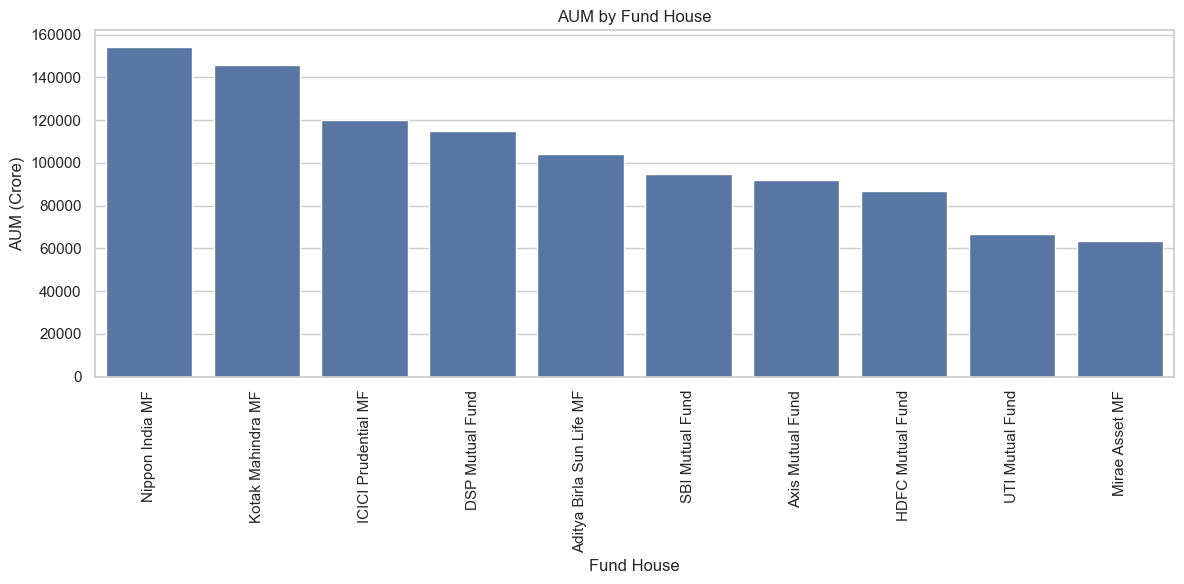

In [12]:
plt.figure(figsize=(12,6))

aum_sorted = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=aum_sorted.index,
    y=aum_sorted.values
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.ylabel("AUM (Crore)")
plt.xlabel("Fund House")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

### Insight 5
Nippon India Mutual Fund recorded the highest aggregate AUM among all fund houses in the dataset, indicating a strong market presence and investor confidence.

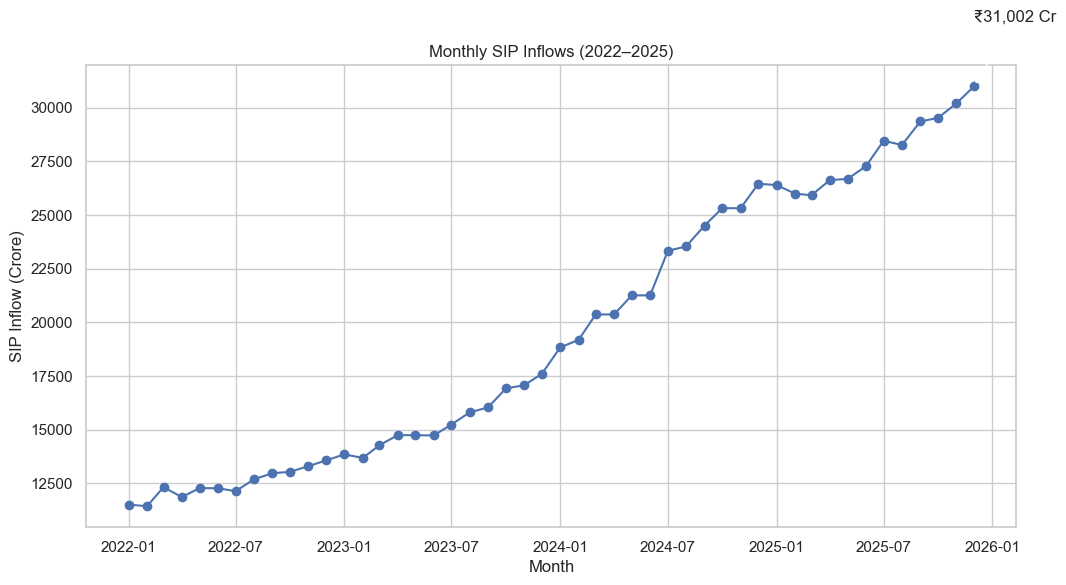

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

plt.annotate(
    "₹31,002 Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] + 3000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.savefig(
    "../reports/charts/sip_inflows.png",
    bbox_inches="tight"
)

plt.show()

### Insight 1
Monthly SIP inflows showed a strong upward trend from 2022 to 2025, reaching an all-time high of ₹31,002 Crore in December 2025.

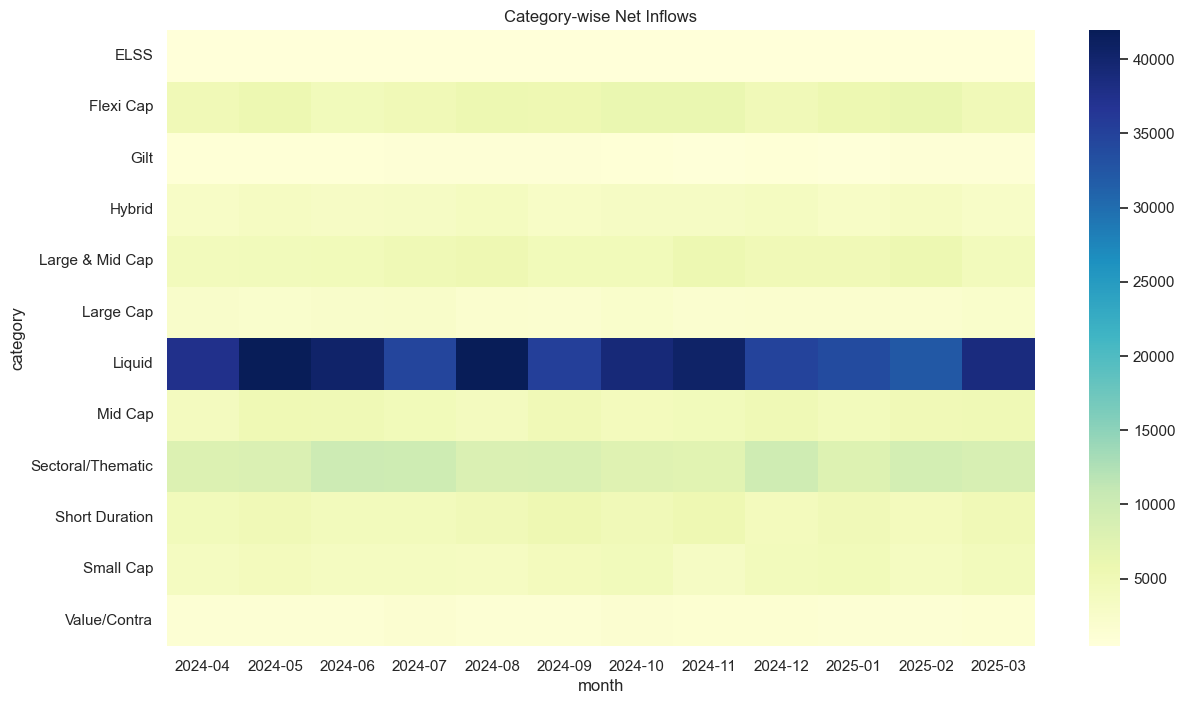

In [16]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")

plt.savefig(
    "../reports/charts/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

### Insight 6
Net inflows varied significantly across fund categories, with certain categories consistently attracting positive investor interest over multiple periods.

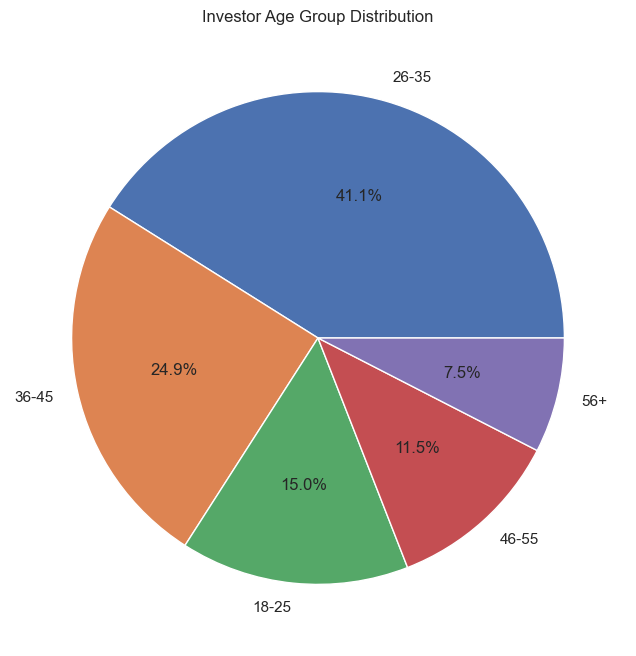

In [17]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

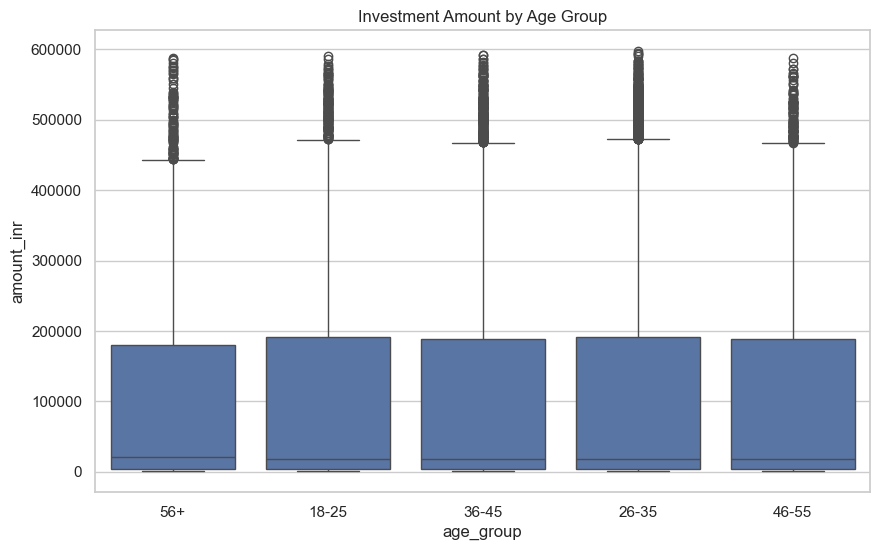

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig(
    "../reports/charts/sip_boxplot_agegroup.png",
    bbox_inches="tight"
)

plt.show()

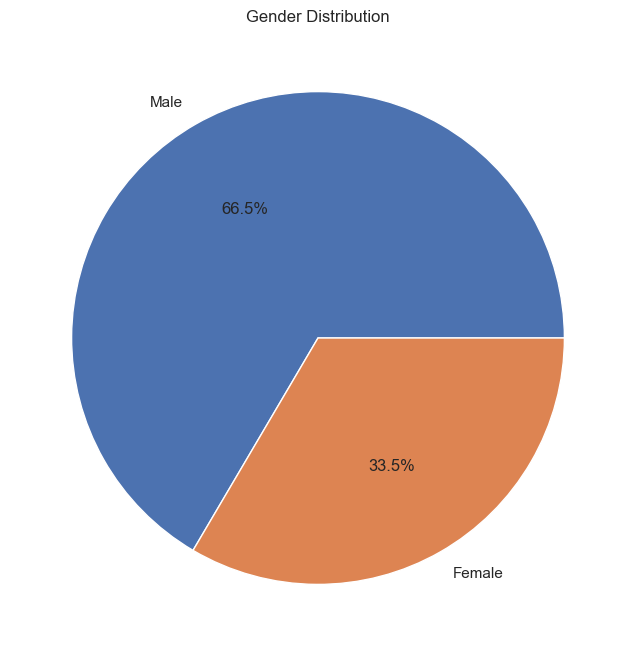

In [19]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight 2
The majority of mutual fund investors belong to the most active working-age segments, indicating strong participation from income-earning groups.

### Insight 3
Investment behaviour varies across age groups, with certain segments contributing significantly higher transaction amounts.

### Insight 4
The investor base shows a measurable gender participation gap, highlighting opportunities for broader market penetration.

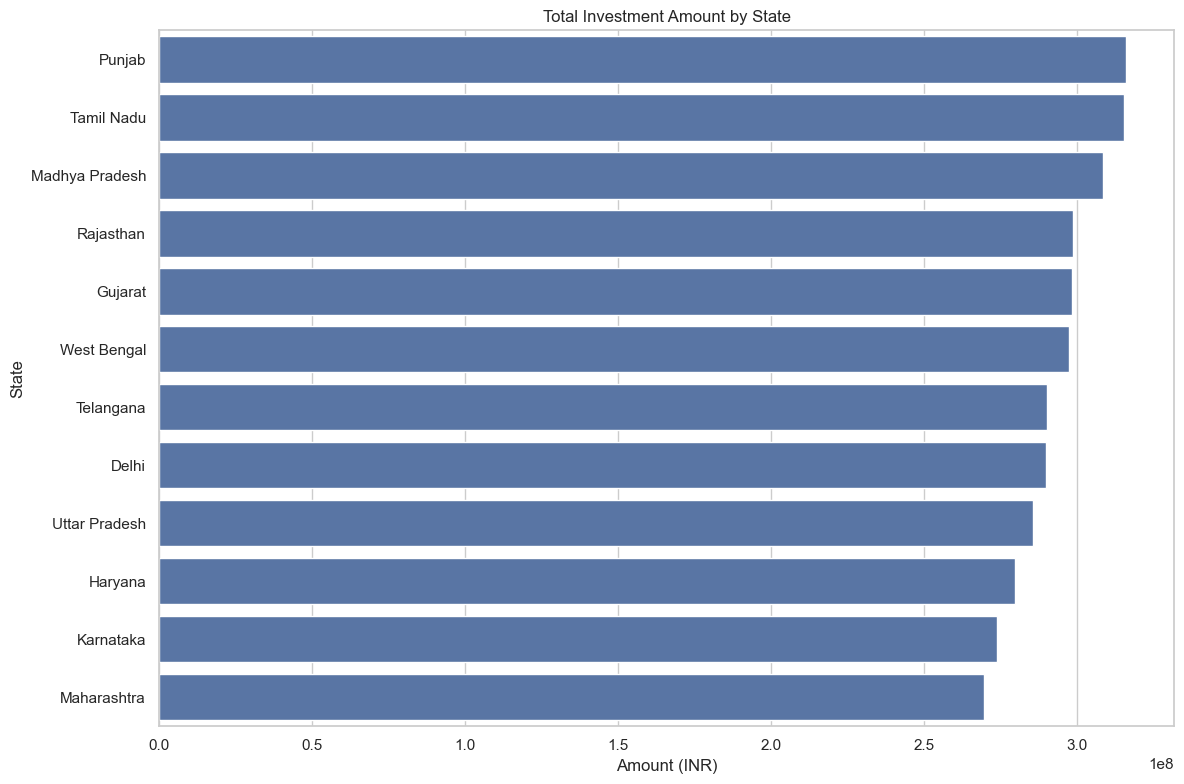

In [20]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/statewise_investment.png",
    bbox_inches="tight"
)

plt.show()

### Insight 7
Investment activity is concentrated in a few major states, highlighting regional differences in mutual fund adoption and participation.

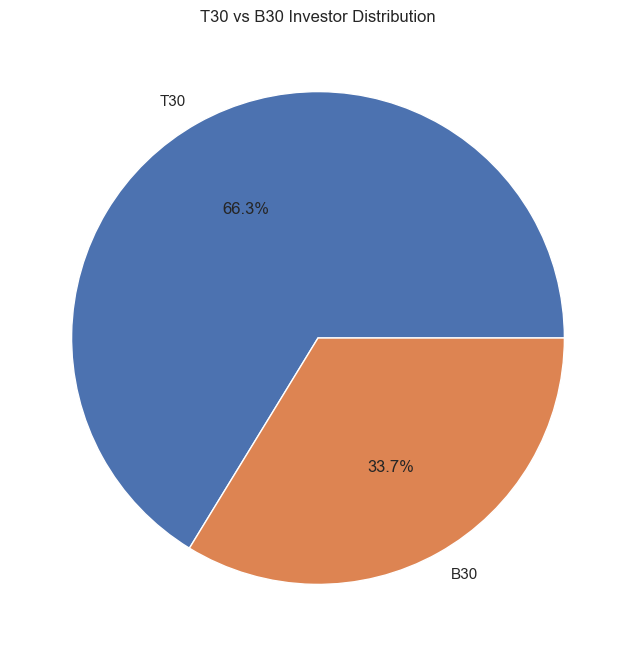

In [21]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight 8
While T30 cities continue to dominate investor participation, B30 cities also contribute a meaningful share, reflecting the expanding reach of mutual fund investments.

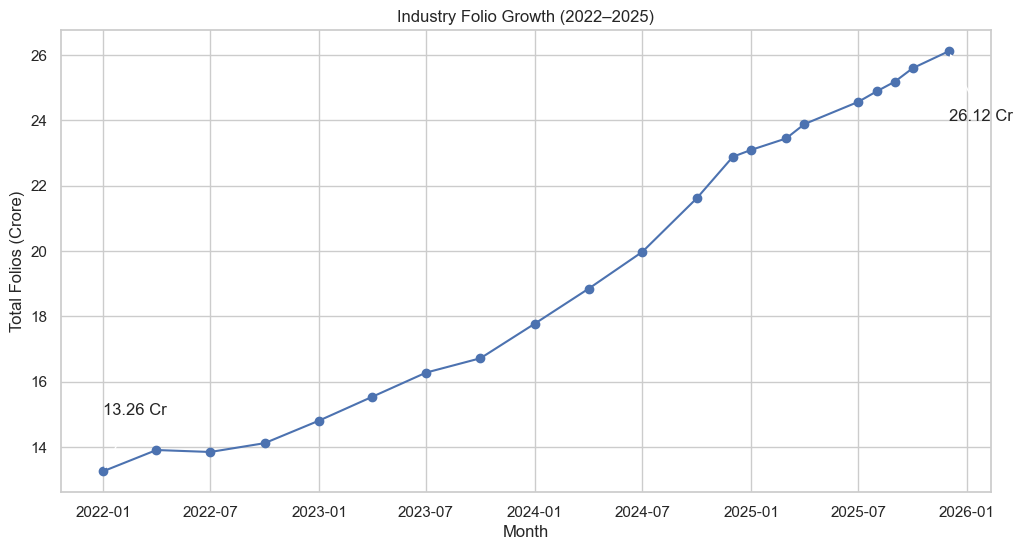

In [27]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    xy=(folios.iloc[0]["month"], folios.iloc[0]["total_folios_crore"]),
    xytext=(folios.iloc[0]["month"], 15),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "26.12 Cr",
    xy=(folios.iloc[-1]["month"], folios.iloc[-1]["total_folios_crore"]),
    xytext=(folios.iloc[-1]["month"], 24),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

### Insight 9
Industry folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, demonstrating rapid growth in investor participation.

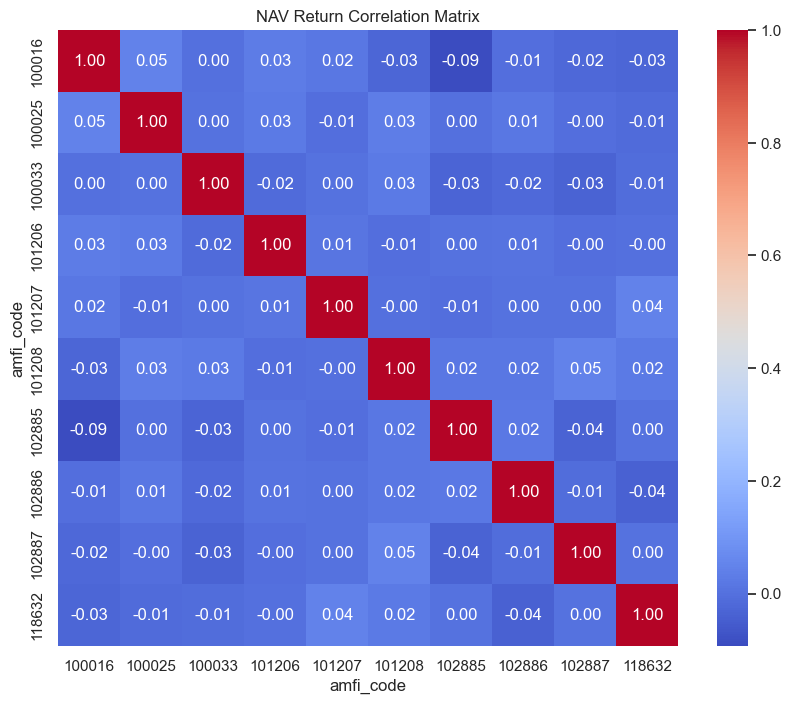

In [28]:
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change().dropna()

corr_matrix = returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "../reports/charts/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Insight 10
Most large-cap mutual funds exhibit strong positive return correlations, indicating that market-wide movements significantly influence fund performance.

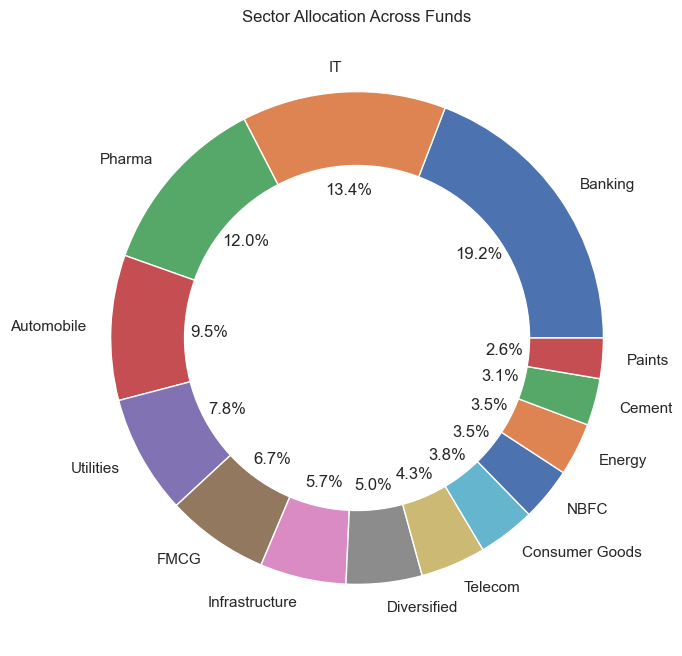

In [29]:
sector_weights = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Funds")

plt.savefig(
    "../reports/charts/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

### Insight 11
The majority of schemes maintain expense ratios within a narrow range, suggesting relatively consistent cost structures across comparable mutual fund categories.

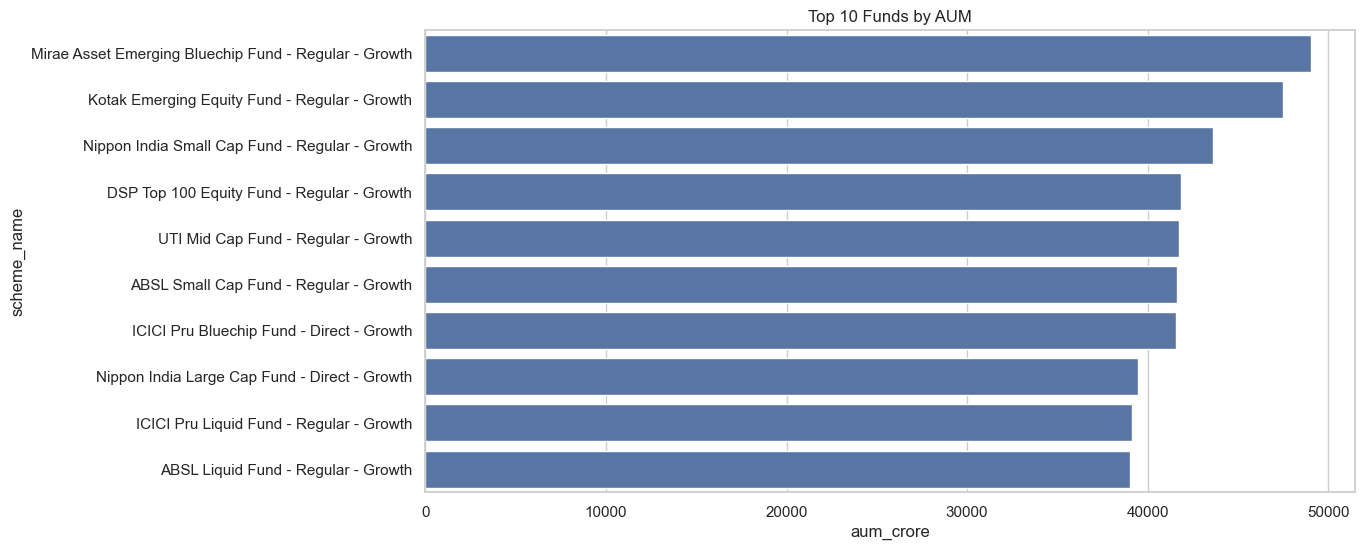

In [30]:
top_funds = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.savefig(
    "../reports/charts/top10_funds_aum.png",
    bbox_inches="tight"
)

plt.show()

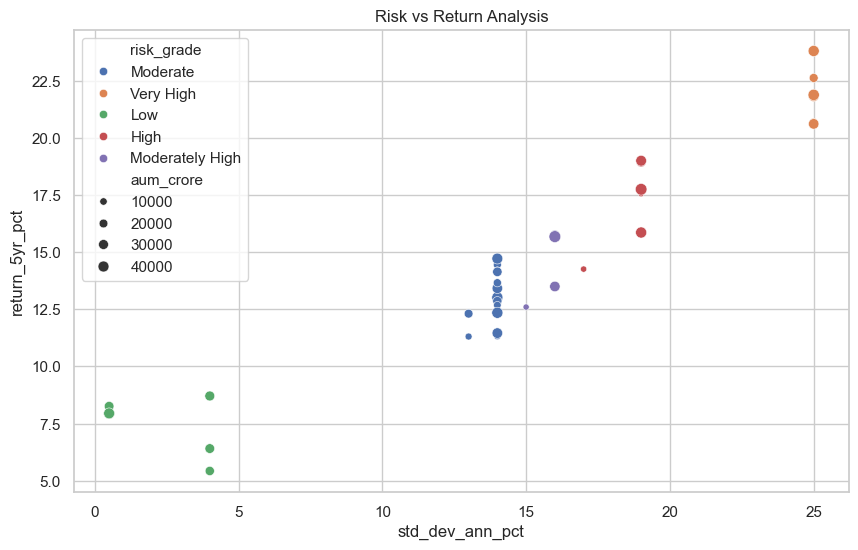

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    size="aum_crore",
    hue="risk_grade"
)

plt.title("Risk vs Return Analysis")

plt.savefig(
    "../reports/charts/risk_return_scatter.png",
    bbox_inches="tight"
)

plt.show()

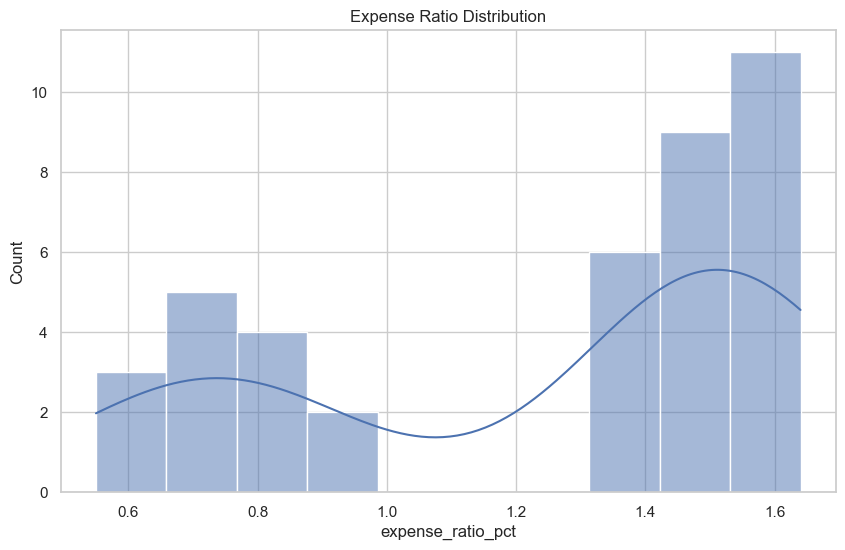

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    bbox_inches="tight"
)

plt.show()

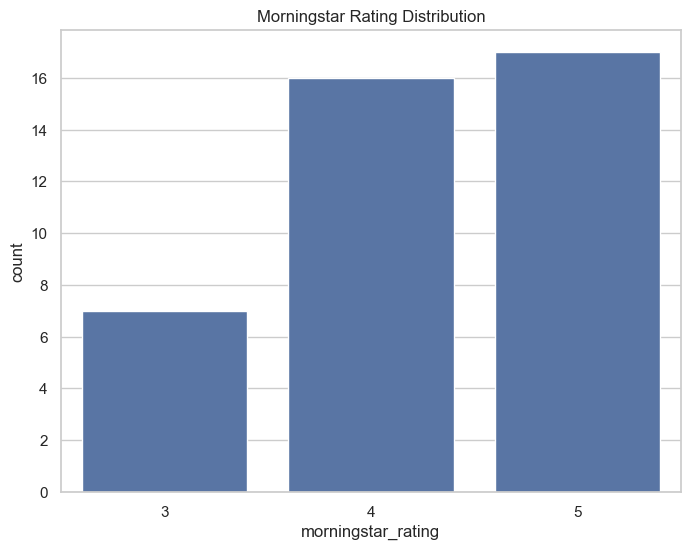

In [33]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.savefig(
    "../reports/charts/morningstar_ratings.png",
    bbox_inches="tight"
)

plt.show()